# Which one is a better plan?

You work as an analyst for the telecom operator Megaline. The company offers its clients two prepaid plans, Surf and Ultimate. The commercial department wants to know which of the plans brings in more revenue in order to adjust the advertising budget.

You are going to carry out a preliminary analysis of the plans based on a relatively small client selection. You'll have the data on 500 Megaline clients: who the clients are, where they're from, which plan they use, and the number of calls they made and text messages they sent in 2018. Your job is to analyze the clients' behavior and determine which prepaid plan brings in more revenue.

# Comparing Two Megaline Telecom Plans: Surf and Ultimate


In this preliminary analysis, we look at data on 500 users from the Surf and Ultimate plans who signed up for these plans in 2018. Five tables tell us:
* Who the users are, where they're from, and the months their subscription was active in 2018
* All service usage by these users by date, including calls, text messages, and internet usage
* Each plan's monthly charge, package limits, and charges after exceeding package limits

We will use these datasets to examine patterns in user behavior, calculate monthly revenue generated by users of each plan, and test two hypotheses:
* The average revenue from users of Ultimate and Surf calling plans differs
* The average revenue from users in NY-NJ area is different from that of the users from other regions



## Initialization

We begin by loading all the libraries we will need for the analysis.

In [1]:
# Loading all the libraries
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as st
import numpy as np


## Load data

Then, we load each of the five datasets and save the results.

In [2]:
# Load the data files into different DataFrames
calls=pd.read_csv('/datasets/megaline_calls.csv')
internet=pd.read_csv('/datasets/megaline_internet.csv')
messages=pd.read_csv('/datasets/megaline_messages.csv')
plans=pd.read_csv('/datasets/megaline_plans.csv')
users=pd.read_csv('/datasets/megaline_users.csv')





## Prepare the data

Now it's time to prepare the data for analysis.

## Plans

We start by calling info and printing a sample of the data to see what it looks like and whether any columns are formatted incorrectly or missing values.

In [3]:
# Print the general/summary information about the plans' DataFrame

plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Print a sample of data for plans

print(plans.head())

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


This dataframe only has two rows, one per plan. There are no missing values in this dataset, no duplicates, and no issues with data types. I prefer to have the plan name as the index instead of the last column for readability.

### Fix data

Here we set the plan_name column as the index.

In [5]:
# set the plan_name as the index
plans=plans.set_index('plan_name',drop=True)

print(plans)

           messages_included  mb_per_month_included  minutes_included  \
plan_name                                                               
surf                      50                  15360               500   
ultimate                1000                  30720              3000   

           usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
plan_name                                                                
surf                    20          10             0.03            0.03  
ultimate                70           7             0.01            0.01  


### Enrich data

It would be helpful to have a column for gb included, since Megaline rounds up mb to gb.

In [6]:
# add a gb per month included column
plans['gb_per_month_included']=plans['mb_per_month_included']/1024
# convert gb column to integer datatype
plans['gb_per_month_included']=plans['gb_per_month_included'].astype(int)
print(plans)

           messages_included  mb_per_month_included  minutes_included  \
plan_name                                                               
surf                      50                  15360               500   
ultimate                1000                  30720              3000   

           usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  \
plan_name                                                                 
surf                    20          10             0.03            0.03   
ultimate                70           7             0.01            0.01   

           gb_per_month_included  
plan_name                         
surf                          15  
ultimate                      30  


## Users

We do the same process for the users dataset.

In [7]:
# Print the general/summary information about the users' DataFrame

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [8]:
# Print a sample of data for users

print(users.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  


In [9]:
# check for duplicate rows
print(users.duplicated().sum())
# check for duplicate values in user_id
print(users.duplicated(subset='user_id').sum())

0
0


There are not duplicates. The reg_date and churn_date columns should be converted to datetime format. The churn_date column is missing a lot of values, which just means the user is still active. The missing values can be filled in with the last day of 2018 (12/31/2018) since we are only looking at 2018 data.

### Fix Data

We now fix the two issues identified above.

In [10]:
# fill missing churn dates with '2018-12-31'
users['churn_date'].fillna('2018-12-31',inplace=True)
# convert reg_date and churn_date columns to datetime format
users[['reg_date', 'churn_date']] = users[['reg_date', 'churn_date']].apply(pd.to_datetime)
# confirm data types are now correct
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  500 non-null    datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


### Enrich Data

It could help to have a column showing users in the NY-NJ area so it's easy to filter NY-NJ users and test whether their average revenue differs.

In [11]:
# print a list of unique values in the city column
users['city'].unique()
# add a column identifying users in the NY-NJ area
# we assume only 'New York-Newark-Jersey City, NY-NJ-PA MSA' users are included in the NY-NJ area
users['ny_nj'] = np.where(users['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA', 1, 0)
# print a sample
print(users.sample(5))

     user_id first_name last_name  age  \
204     1204     Sherly      Levy   44   
447     1447      Ramon    Hester   62   
109     1109    Dominic   Salinas   41   
107     1107       Lane      Cash   61   
331     1331  Lashandra     Ramos   54   

                                          city   reg_date      plan  \
204     Chicago-Naperville-Elgin, IL-IN-WI MSA 2018-08-20  ultimate   
447          Orlando-Kissimmee-Sanford, FL MSA 2018-05-01      surf   
109  New York-Newark-Jersey City, NY-NJ-PA MSA 2018-02-16      surf   
107  New York-Newark-Jersey City, NY-NJ-PA MSA 2018-11-15  ultimate   
331        Dallas-Fort Worth-Arlington, TX MSA 2018-02-06      surf   

    churn_date  ny_nj  
204 2018-12-31      0  
447 2018-12-31      0  
109 2018-12-31      1  
107 2018-12-31      1  
331 2018-12-31      0  


## Calls

We do the same process for the calls dataset.

In [12]:
# Print the general/summary information about the calls' DataFrame
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [13]:
# Print a sample of data for calls
print(calls.head())


         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


In [14]:
# check for duplicate rows
print(calls.duplicated().sum())
# check for duplicate values in id
print(calls.duplicated(subset='id').sum())

0
0


No missing data or duplicates. Renaming the id column to call_id could reduce confusion when looking at the different usage tables. Duration needs to be rounded up to whole minutes for each individual call since Megaline counts even a 1-second call as one minute, and call_date should be converted to datetime format.

### Fix data

We now fix the issues identified above.

In [15]:
# convert duration to int and round all values up
calls['duration'] = np.ceil(calls['duration']).astype(int)
# convert call_date to datetime
calls['call_date'] = calls['call_date'].apply(pd.to_datetime)
# rename id column
calls=calls.rename(columns={'id':'call_id'})
# call info to confirm correct data types and column names
calls.info()
# print head to confirm correct rounding 
print(calls.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   call_id    137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 4.2+ MB
    call_id  user_id  call_date  duration
0   1000_93     1000 2018-12-27         9
1  1000_145     1000 2018-12-27        14
2  1000_247     1000 2018-12-27        15
3  1000_309     1000 2018-12-28         6
4  1000_380     1000 2018-12-30         5


### Enrich data

Adding a column for call month will make it easy to group by month.

In [16]:
# add a column for call month to make it easy to group by month
calls['month']=calls['call_date'].dt.month
print(calls.head())

    call_id  user_id  call_date  duration  month
0   1000_93     1000 2018-12-27         9     12
1  1000_145     1000 2018-12-27        14     12
2  1000_247     1000 2018-12-27        15     12
3  1000_309     1000 2018-12-28         6     12
4  1000_380     1000 2018-12-30         5     12


## Messages

We do the same process for the messages dataset.

In [17]:
# Print the general/summary information about the messages' DataFrame
messages.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [18]:
# Print a sample of data for messages

print(messages.head())

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


In [19]:
# check for duplicate rows
print(messages.duplicated().sum())
# check for duplicate values in id
print(messages.duplicated(subset='id').sum())

0
0


No missing values or duplicates. The message_date column needs to be converted to datetime, and id should be renamed to message_id for clarity.

### Fix data

We now fix the issues identified above.

In [20]:
# convert message_date to datetime
messages['message_date'] = messages['message_date'].apply(pd.to_datetime)
# rename id column
messages=messages.rename(columns={'id':'message_id'})
# call info to confirm correct data types and column names
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   message_id    76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enrich data

Adding a column for message month will make it easy to group by month.

In [21]:
# add a column for message month to make it easy to group by month
messages['month']=messages['message_date'].dt.month
print(messages.head())

  message_id  user_id message_date  month
0   1000_125     1000   2018-12-27     12
1   1000_160     1000   2018-12-31     12
2   1000_223     1000   2018-12-31     12
3   1000_251     1000   2018-12-27     12
4   1000_255     1000   2018-12-26     12


## Internet

We do the same process for the internet dataset.

In [22]:
# Print the general/summary information about the internet DataFrame
internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [23]:
# Print a sample of data for the internet traffic
print(internet.head())


         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


No missing data. The session_date column should be converted to datetime, and id should be renamed to session_id for clarity.

### Fix data

We now fix the issues identified above.

In [24]:
# convert session_date to datetime
internet['session_date'] = internet['session_date'].apply(pd.to_datetime)
# rename id column
internet=internet.rename(columns={'id':'session_id'})
# call info to confirm correct data types and column names
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   session_id    104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


### Enrich data

Adding a column for session month will make it easy to group by month.

In [25]:
# add a column for session month to make it easy to group by month
internet['month']=internet['session_date'].dt.month
print(internet.head())

  session_id  user_id session_date  mb_used  month
0    1000_13     1000   2018-12-29    89.86     12
1   1000_204     1000   2018-12-31     0.00     12
2   1000_379     1000   2018-12-28   660.40     12
3   1000_413     1000   2018-12-26   270.99     12
4   1000_442     1000   2018-12-27   880.22     12


## Study plan conditions

To understand how the plans work and how users are charged based on their plan subscription, we print out the plan information to view their conditions once again.

In [26]:
# Print out the plan conditions and make sure they are clear

print(plans)

           messages_included  mb_per_month_included  minutes_included  \
plan_name                                                               
surf                      50                  15360               500   
ultimate                1000                  30720              3000   

           usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  \
plan_name                                                                 
surf                    20          10             0.03            0.03   
ultimate                70           7             0.01            0.01   

           gb_per_month_included  
plan_name                         
surf                          15  
ultimate                      30  


The plans table shows the conditions for each plan. Note: Megaline rounds seconds up to minutes, and megabytes to gigabytes. For calls, each individual call is rounded up: even if the call lasted just one second, it will be counted as one minute. For web traffic, individual web sessions are not rounded up. Instead, the total for the month is rounded up. If someone uses 1025 megabytes this month, they will be charged for 2 gigabytes. There are 1024 megabytes in a gigabyte.

## Aggregate data per user

Now, as the data is clean, we aggregate data per user per period in order to have just one record per user per period.

We start with the call data, then messages, then internet.

In [27]:
# Calculate the number of calls made by each user per month. Save the result.
monthly_calls=calls.groupby(['user_id', 'month']).size().reset_index(name='call_count')
# sort values for readability
monthly_calls = monthly_calls.sort_values(by=['user_id', 'month'])
print(monthly_calls)


      user_id  month  call_count
0        1000     12          16
1        1001      8          27
2        1001      9          49
3        1001     10          65
4        1001     11          64
...       ...    ...         ...
2253     1498     12          39
2254     1499      9          41
2255     1499     10          53
2256     1499     11          45
2257     1499     12          65

[2258 rows x 3 columns]


In [28]:
# Calculate the amount of minutes spent by each user per month. Save the result.
monthly_minutes=calls.groupby(['user_id', 'month'])['duration'].sum().reset_index(name='call_minutes')
# sort values for readability
monthly_minutes = monthly_minutes.sort_values(by=['user_id', 'month'])
print(monthly_minutes)


      user_id  month  call_minutes
0        1000     12           124
1        1001      8           182
2        1001      9           315
3        1001     10           393
4        1001     11           426
...       ...    ...           ...
2253     1498     12           339
2254     1499      9           346
2255     1499     10           385
2256     1499     11           308
2257     1499     12           496

[2258 rows x 3 columns]


In [29]:
# Calculate the number of messages sent by each user per month. Save the result.
monthly_messages=messages.groupby(['user_id', 'month']).size().reset_index(name='message_count')
# sort values for readability
monthly_messages = monthly_messages.sort_values(by=['user_id', 'month'])
print(monthly_messages)

      user_id  month  message_count
0        1000     12             11
1        1001      8             30
2        1001      9             44
3        1001     10             53
4        1001     11             36
...       ...    ...            ...
1801     1496      9             21
1802     1496     10             18
1803     1496     11             13
1804     1496     12             11
1805     1497     12             50

[1806 rows x 3 columns]


In [30]:
# Calculate the volume of internet traffic used by each user per month. Save the result.
monthly_gb=internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index(name='monthly_mb')
# add a gb column rounding up mb monthly total to gb
monthly_gb['monthly_gb']=np.ceil(monthly_gb['monthly_mb']/1024).astype(int)
# sort values for readability
monthly_gb = monthly_gb.sort_values(by=['user_id', 'month'])
print(monthly_gb)


      user_id  month  monthly_mb  monthly_gb
0        1000     12     1901.47           2
1        1001      8     6919.15           7
2        1001      9    13314.82          14
3        1001     10    22330.49          22
4        1001     11    18504.30          19
...       ...    ...         ...         ...
2272     1498     12    23137.69          23
2273     1499      9    12984.76          13
2274     1499     10    19492.43          20
2275     1499     11    16813.83          17
2276     1499     12    22059.21          22

[2277 rows x 4 columns]


Now we put the aggregate data together into one DataFrame so that one record in it represents what an unique user consumed in a given month.

In [31]:
# Merge the data for calls, minutes, messages, internet based on user_id and month
monthly_usage=pd.merge(monthly_calls,monthly_minutes, on=['user_id','month'],how='outer')
monthly_usage=pd.merge(monthly_usage,monthly_messages, on=['user_id','month'],how='outer')
monthly_usage=pd.merge(monthly_usage,monthly_gb, on=['user_id','month'],how='outer')
# sort values for readability
monthly_usage = monthly_usage.sort_values(by=['user_id', 'month'])
# reset index 
monthly_usage = monthly_usage.reset_index(drop=True)
print(monthly_usage)
monthly_usage.info()


      user_id  month  call_count  call_minutes  message_count  monthly_mb  \
0        1000     12        16.0         124.0           11.0     1901.47   
1        1001      8        27.0         182.0           30.0     6919.15   
2        1001      9        49.0         315.0           44.0    13314.82   
3        1001     10        65.0         393.0           53.0    22330.49   
4        1001     11        64.0         426.0           36.0    18504.30   
...       ...    ...         ...           ...            ...         ...   
2288     1498     12        39.0         339.0            NaN    23137.69   
2289     1499      9        41.0         346.0            NaN    12984.76   
2290     1499     10        53.0         385.0            NaN    19492.43   
2291     1499     11        45.0         308.0            NaN    16813.83   
2292     1499     12        65.0         496.0            NaN    22059.21   

      monthly_gb  
0            2.0  
1            7.0  
2           14.0  

After merging it looks like there are some missing values. This makes sense, as not every user uses every service every month. It does seem a bit odd that text message usage is so much lower than calls and internet, but it could be that messages only counts SMS messages, and messages sent on wifi don't count. We can assume that the missing values mean no usage, or 0. We need to fill in the NaN values with zeroes because they need to be factored into the mean calculations later.

In [32]:
# fill in missing values with 0
monthly_usage.fillna(0, inplace=True)
# print to confirm
print(monthly_usage.head(20))
# confirm no missing values remain 
print(monthly_usage.isnull().sum())

    user_id  month  call_count  call_minutes  message_count  monthly_mb  \
0      1000     12        16.0         124.0           11.0     1901.47   
1      1001      8        27.0         182.0           30.0     6919.15   
2      1001      9        49.0         315.0           44.0    13314.82   
3      1001     10        65.0         393.0           53.0    22330.49   
4      1001     11        64.0         426.0           36.0    18504.30   
5      1001     12        56.0         412.0           44.0    19369.18   
6      1002     10        11.0          59.0           15.0     6552.01   
7      1002     11        55.0         386.0           32.0    19345.08   
8      1002     12        47.0         384.0           41.0    14396.24   
9      1003     12       149.0        1104.0           50.0    27044.14   
10     1004      5        21.0         193.0            7.0     6547.21   
11     1004      6        44.0         275.0           18.0    20672.82   
12     1004      7       

We also want to check if there were any months where a user was subscribed, but didn't use any of the three services. We can refer to the users table for this: the range of months between each user's registration date and churn date defines their active months.

In [33]:
# filter users table
users_active_months=users[['user_id','reg_date','churn_date']]
# make a copy
users_active_months = users_active_months.copy()
# add a column with the count of active months
users_active_months['active_months']=((users_active_months['churn_date'].dt.month - users_active_months['reg_date'].dt.month) + 1)
print(users_active_months.head())

   user_id   reg_date churn_date  active_months
0     1000 2018-12-24 2018-12-31              1
1     1001 2018-08-13 2018-12-31              5
2     1002 2018-10-21 2018-12-31              3
3     1003 2018-01-28 2018-12-31             12
4     1004 2018-05-23 2018-12-31              8


Now we have the count of active (subscribed) months for each user. If this doesn't match the count of months in the monthly_usage table, we'll need to add more rows to the monthly_usage table to account for all active months for each user.

In [34]:
# Calculate the active usage months for each user
monthly_users_active_months=monthly_usage.groupby('user_id')['month'].count().reset_index(name='active_months_usage')
print(monthly_users_active_months.head())
# call info
monthly_users_active_months.info()
# merge the two datasets to compare
merged_active_months=users_active_months.merge(monthly_users_active_months, on='user_id',how='outer')
merged_active_months.info()
# print the rows where the number of active months don't match the number of usage months
print(merged_active_months[merged_active_months['active_months'] != merged_active_months['active_months_usage']])

   user_id  active_months_usage
0     1000                    1
1     1001                    5
2     1002                    3
3     1003                    1
4     1004                    8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490 entries, 0 to 489
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   user_id              490 non-null    int64
 1   active_months_usage  490 non-null    int64
dtypes: int64(2)
memory usage: 7.8 KB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              500 non-null    int64         
 1   reg_date             500 non-null    datetime64[ns]
 2   churn_date           500 non-null    datetime64[ns]
 3   active_months        500 non-null    int64         
 4   active_months_usage  49

It turns out 275/500 users have at least one month where they paid the subscription fee but didn't use any services, and 10 subscribed users have never used any services! We need to add all the months that each user was subscribed into the monthly_usage table and fill in the usage values in those rows as 0 for each service to calculate the usage statistics correctly. <br> <br> First, we create a table with one record per user per month they were subscribed, referencing the users table. Each row represents a month that the user paid the monthly subscription charge. Megaline's billing cycle policy is not provided, so we will assume a user is charged for the full month even if they register late in the month, and we will also assume they get charged on the 1st of the month every month thereafter.

In [35]:
# define function to generate rows per subscribed months
def months_subscribed(user):
    # function resets registration date day to 1 to include registration month
    return pd.DataFrame({
        'user_id': user['user_id'],
        'month': pd.date_range(
            user['reg_date'].replace(day=1), user['churn_date'], freq='MS'
        ).month  # extract subscribed months (1-12)
    })

# apply function to each user and concatenate results
users_subscribed_months = pd.concat(users.apply(months_subscribed, axis=1).tolist(), ignore_index=True)

print(users_subscribed_months.head(10))

   user_id  month
0     1000     12
1     1001      8
2     1001      9
3     1001     10
4     1001     11
5     1001     12
6     1002     10
7     1002     11
8     1002     12
9     1003      1


Then, we merge with the monthly_usage table and fill in NaN values with 0.

In [36]:
# outer merge with monthly_usage table
monthly_activity=users_subscribed_months.merge(monthly_usage, on=['user_id','month'],how='outer')
print(monthly_activity.head(10))
# fill in missing values
monthly_activity.fillna(0, inplace=True)
# confirm no missing values remain 
print(monthly_activity.isnull().sum())

   user_id  month  call_count  call_minutes  message_count  monthly_mb  \
0     1000     12        16.0         124.0           11.0     1901.47   
1     1001      8        27.0         182.0           30.0     6919.15   
2     1001      9        49.0         315.0           44.0    13314.82   
3     1001     10        65.0         393.0           53.0    22330.49   
4     1001     11        64.0         426.0           36.0    18504.30   
5     1001     12        56.0         412.0           44.0    19369.18   
6     1002     10        11.0          59.0           15.0     6552.01   
7     1002     11        55.0         386.0           32.0    19345.08   
8     1002     12        47.0         384.0           41.0    14396.24   
9     1003      1         NaN           NaN            NaN         NaN   

   monthly_gb  
0         2.0  
1         7.0  
2        14.0  
3        22.0  
4        19.0  
5        19.0  
6         7.0  
7        19.0  
8        15.0  
9         NaN  
user_id  

Now our table has a row per active/subscribed month per user. Next, we add the plan that each user is on.

In [37]:
# add the plan information from the users table
monthly_activity=pd.merge(monthly_activity, users[['user_id','plan']], on='user_id', how='left')
print(monthly_activity.head(10))

   user_id  month  call_count  call_minutes  message_count  monthly_mb  \
0     1000     12        16.0         124.0           11.0     1901.47   
1     1001      8        27.0         182.0           30.0     6919.15   
2     1001      9        49.0         315.0           44.0    13314.82   
3     1001     10        65.0         393.0           53.0    22330.49   
4     1001     11        64.0         426.0           36.0    18504.30   
5     1001     12        56.0         412.0           44.0    19369.18   
6     1002     10        11.0          59.0           15.0     6552.01   
7     1002     11        55.0         386.0           32.0    19345.08   
8     1002     12        47.0         384.0           41.0    14396.24   
9     1003      1         0.0           0.0            0.0        0.00   

   monthly_gb      plan  
0         2.0  ultimate  
1         7.0      surf  
2        14.0      surf  
3        22.0      surf  
4        19.0      surf  
5        19.0      surf  
6  

Now we can calculate the monthly revenue from each user. To do this, we need to subtract the free package limit from the total number of calls, text messages, and data; multiply the result by the calling plan value; and finally, add the monthly charge depending on the calling plan.

In [38]:
# define a function to calculate monthly revenue based on the values in each row of the monthly_activity table

def monthly_revenue(row):
    # define calculation for users on the Ultimate plan based on Ultimate conditions
    if row['plan'] == 'ultimate':
    # use conditional logic to calculate charges for calls, texts, and internet usage
        # if the user stayed within 3000 monthly minutes, there is no extra charge
        if row['call_minutes'] <= 3000:
            call_charge = 0
        # if the user exceeded the limit, they will be charged 1 cent for each extra minute
        else:
            call_charge = (row['call_minutes']-3000)*.01
        # if the user stayed within 1000 monthly texts, there is no extra charge
        if row['message_count'] <= 1000:
            message_charge = 0
        # if the user exceeded the limit, they will be charged 1 cent for each extra text
        else:
            message_charge = (row['message_count']-1000)*.01
        # if the user stayed within 30 GB of data, there is no extra charge
        if row['monthly_gb'] <= 30:
            internet_charge = 0
        # if the user exceeded the limit, they will be charged 7 dollars for each extra GB
        else:
            internet_charge = (row['monthly_gb']-30)*7
        # monthly revenue is the subscription fee plus any additional charges for above-limit usage      
        monthly_revenue_ultimate = 70 + call_charge + message_charge + internet_charge
        # return result
        return monthly_revenue_ultimate
    # define calculation for users on the Surf plan based on Surf conditions
    if row['plan'] == 'surf':
    # use conditional logic to calculate charges for calls, texts, and internet usage
        # if the user stayed within 500 monthly minutes, there is no extra charge
        if row['call_minutes'] <= 500:
            call_charge = 0
        # if the user exceeded the limit, they will be charged 3 cents for each extra minute
        else:
            call_charge = (row['call_minutes']-500)*.03
        # if the user stayed within 50 monthly texts, there is no extra charge
        if row['message_count'] <= 50:
            message_charge = 0
        # if the user exceeded the limit, they will be charged 3 cents for each extra text
        else:
            message_charge = (row['message_count']-50)*.03
        # if the user stayed within 15 GB of data, there is no extra charge
        if row['monthly_gb'] <= 15:
            internet_charge = 0
        # if the user exceeded the limit, they will be charged 10 dollars for each extra GB
        else:
            internet_charge = (row['monthly_gb']-15)*10
        # monthly revenue is the subscription fee plus any additional charges for above-limit usage
        monthly_revenue_surf = 20 + call_charge + message_charge + internet_charge
        # return result
        return monthly_revenue_surf
    
# apply function to the monthly_activity table to create a column showing the monthly revenue for each user
monthly_activity['monthly_revenue']=monthly_activity.apply(monthly_revenue, axis=1)
# print the result
print(monthly_activity.head())

   user_id  month  call_count  call_minutes  message_count  monthly_mb  \
0     1000     12        16.0         124.0           11.0     1901.47   
1     1001      8        27.0         182.0           30.0     6919.15   
2     1001      9        49.0         315.0           44.0    13314.82   
3     1001     10        65.0         393.0           53.0    22330.49   
4     1001     11        64.0         426.0           36.0    18504.30   

   monthly_gb      plan  monthly_revenue  
0         2.0  ultimate            70.00  
1         7.0      surf            20.00  
2        14.0      surf            20.00  
3        22.0      surf            90.09  
4        19.0      surf            60.00  


Now we can see the monthly revenue generated from each user in USD.

## Study user behaviour

Before digging into specific usage patterns, it's helpful to see how many active monthly users we have for each plan in our dataset.

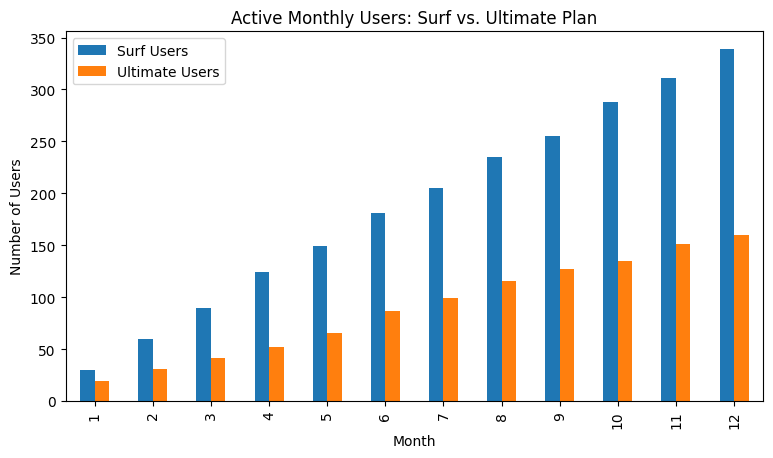

In [39]:
# create a pivot table showing the count of monthly users per plan per month
monthly_users_pivot=monthly_activity.pivot_table(index='month', columns='plan', values='user_id', aggfunc='count')

# plot a bar chart to visualize the distribution
monthly_users_pivot_plot=monthly_users_pivot.plot(kind='bar', xlabel="Month", ylabel='Number of Users', title='Active Monthly Users: Surf vs. Ultimate Plan',figsize=(9,4.8))
monthly_users_pivot_plot.legend(['Surf Users','Ultimate Users'])

plt.show()

The bar chart shows the number of active monthly users increasing steadily each month. This make sense, as the dataset only includes users who registered for one of the two plans in 2018, and only 34 of the 500 users "churned" or dropped out before the end of the year. <br> <br> It's important to keep in mind that the sample size of Surf users is more than double the sample size of Ultimate users, and the sample sizes are significantly larger for later months than for earlier months. Smaller sample sizes make any conclusions a bit less certain.

Now we'll calculate some useful descriptive statistics for the aggregated and merged data, which typically reveal an overall picture captured by the data. We draw bar charts and histograms to help the understanding. Given that the main task is to compare the plans and decide on which one is more profitable, the statistics and the plots are calculated on a per-plan basis.

### Calls

We start with analyzing call behavior. First, we look at the average (mean) duration of calls per plan per month.

plan         surf    ultimate
month                        
1       13.533333   40.736842
2       44.550000   91.032258
3       84.333333   89.048780
4      141.750000  136.038462
5      206.496644  181.246154
6      231.138122  200.402299
7      265.600000  254.515152
8      282.714894  257.948276
9      315.137255  296.267717
10     353.631944  353.911111
11     385.212219  374.437086
12     444.483776  433.275000



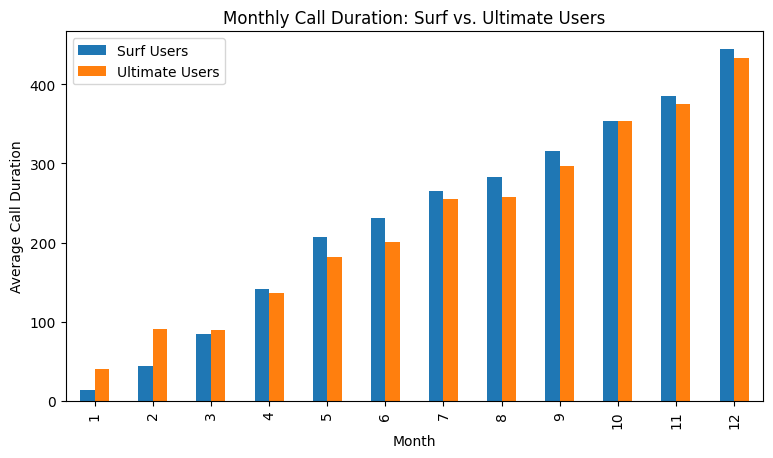

In [40]:
# Compare average duration of calls per each plan per each distinct month. Plot a bar plot to visualize it.
# create a pivot table with the mean call minutes by plan by month
monthly_call_pivot=monthly_activity.pivot_table(index='month', columns='plan', values='call_minutes', aggfunc='mean')
print(monthly_call_pivot)
print()
# plot a bar chart based on the pivot table
monthly_call_pivot_plot=monthly_call_pivot.plot(kind='bar', xlabel="Month", ylabel='Average Call Duration', title='Monthly Call Duration: Surf vs. Ultimate Users',figsize=(9,4.8))
monthly_call_pivot_plot.legend(['Surf Users','Ultimate Users'])
plt.show()

It looks like average monthly call duration is typically a bit higher for Surf users than for Ultimate users. This seems surprising at first considering Surf users have fewer monthly minutes, but they still seem to be staying under their monthly allottment of 500 minutes. And, when looking at just calls, it doesn't seem like Ultimate users are using anywhere near their 3000 monthly minutes. <br> <br>
More interestingly, the plot shows average call durations increasing each month. This could be because users take some time after subscribing to get into the habit of actually using the plan services. Users might also grow more comfortable with increasing their usage over time once they see that they are staying within their package limits. It would be interesting to see if usage levels out at some point in the following year, or if it continues to increase.

Next, we'll plot a histogram to visualize the distribution of user behavior.

         call_minutes
user_id              
1001       345.600000
1002       276.333333
1003        92.000000
1004       346.500000
1005       248.000000
         call_minutes
user_id              
1000           124.00
1006            34.50
1008           311.20
1011           242.25
1013           219.00



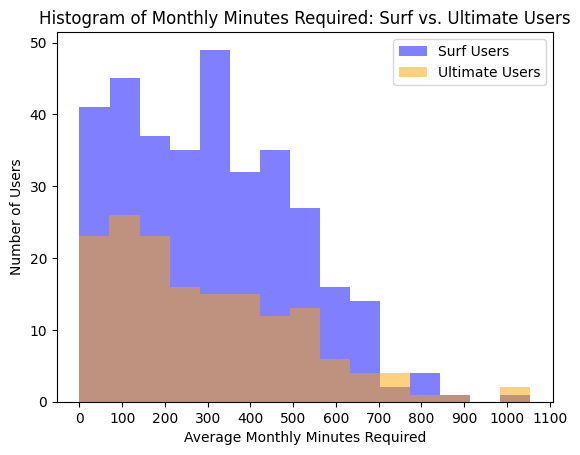

In [41]:
# Compare the number of minutes users of each plan require each month. Plot a histogram.
# filter monthly_activity to create a dataset for each plan
surf_minutes=monthly_activity[monthly_activity['plan']=='surf']
ultimate_minutes=monthly_activity[monthly_activity['plan']=='ultimate']
# create a pivot table for each plan showing average monthly minutes used per user
surf_required_minutes=surf_minutes.pivot_table(index='user_id', values='call_minutes', aggfunc='mean')
ultimate_required_minutes=ultimate_minutes.pivot_table(index='user_id', values='call_minutes', aggfunc='mean')
# print results
print(surf_required_minutes.head())
print(ultimate_required_minutes.head())
print()
# plot histograms for both pivot tables
plt.hist(surf_required_minutes['call_minutes'], bins=15, alpha=0.5, color='blue', label='Surf Users')
plt.hist(ultimate_required_minutes['call_minutes'], bins=15, alpha=0.5, color='orange', label='Ultimate Users')
# add chart elements
plt.xlabel('Average Monthly Minutes Required')
plt.ylabel('Number of Users')
plt.title('Histogram of Monthly Minutes Required: Surf vs. Ultimate Users')
plt.legend(['Surf Users','Ultimate Users'])
plt.locator_params(axis='x', nbins=15)

plt.show()


This histogram is right-skewed, meaning users of both plans more frequently require lower amounts of monthly minutes vs. higher amounts. Surf users most frequently require between 300 and 350 monthly minutes, while Ultimate users most frequently require between 50 and 150. Ultimate users are not using anywhere close to their monthly limit. While a portion of Surf users are going beyond their monthly limit, the extra cost is still cheaper than an Ultimate subscription, and very few Surf users use more than 850 monthly minutes.

Now we calculate the mean, variance, and standard deviation of the call duration to reason on whether users on the different plans have different behaviours for their calls.

In [42]:
# Calculate the mean, variance, and standard deviation of the monthly call duration

# calculate mean of monthly call duration for each plan
surf_minutes_mean=surf_minutes['call_minutes'].mean()
ultimate_minutes_mean=ultimate_minutes['call_minutes'].mean()
# calculate variance of monthly call duration for each plan
surf_minutes_variance=np.var(surf_minutes['call_minutes'])
ultimate_minutes_variance=np.var(ultimate_minutes['call_minutes'])
# calculate standard deviation as the square root of the variance
surf_minutes_std=np.sqrt(surf_minutes_variance)
ultimate_minutes_std=np.sqrt(ultimate_minutes_variance)


# print results
print('Mean monthly call duration, Surf users:',surf_minutes_mean)
print('Mean monthly call duration, Ultimate users:',ultimate_minutes_mean)
print('Variance of monthly call duration, Surf users:',surf_minutes_variance)
print('Variance of monthly call duration, Ultimate users:',ultimate_minutes_variance)
print('Standard deviation of monthly call duration, Surf users:',surf_minutes_std)
print('Standard deviation of monthly call duration, Ultimate users:',ultimate_minutes_std)

Mean monthly call duration, Surf users: 297.4958094397883
Mean monthly call duration, Ultimate users: 286.17174515235456
Variance of monthly call duration, Surf users: 77163.94296876475
Variance of monthly call duration, Ultimate users: 79691.10254423053
Standard deviation of monthly call duration, Surf users: 277.78398616328616
Standard deviation of monthly call duration, Ultimate users: 282.2961256273818


The mean, variance, and standard deviation is slightly higher for Ultimate users, suggesting more usage and a wider distribution. <br><br> Now, we plot boxplots to visualize the distribution for each plan's users.

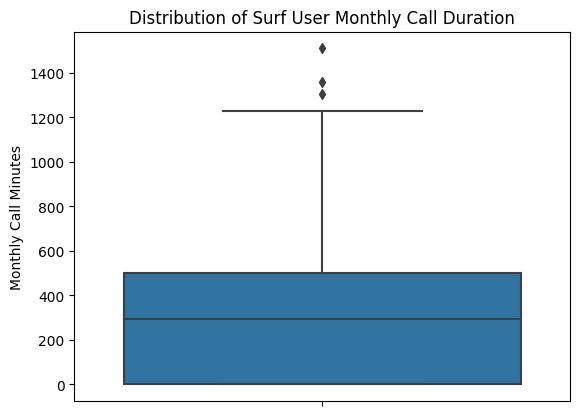

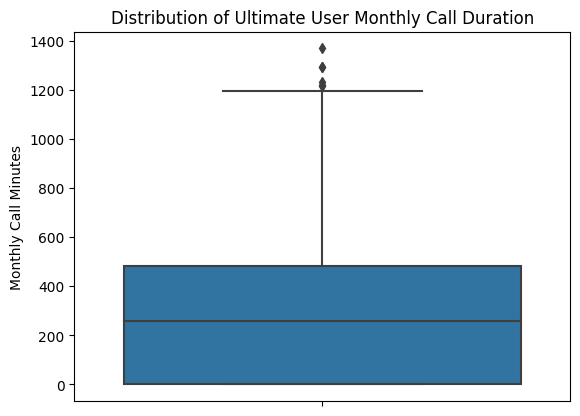

In [43]:
# Plot a boxplot to visualize the distribution of the monthly call duration

# create boxplot for Surf users
sns.boxplot(y=surf_minutes['call_minutes'])

# add labels
plt.title('Distribution of Surf User Monthly Call Duration')
plt.ylabel('Monthly Call Minutes')

plt.show()

# create boxplot for Ultimate users
sns.boxplot(y=ultimate_minutes['call_minutes'])

# add labels
plt.title('Distribution of Ultimate User Monthly Call Duration')
plt.ylabel('Monthly Call Minutes')

plt.show()



Users on both plans have fairly similar call behavior. The minimum values and 1st quartile are the same for both, suggesting a large portion of months where users did not make any calls. The median, 3rd quartile, and 4th quartile are slightly higher for Ultimate users, and Ultimate users also have a few more outlier values. This makes sense considering the Ultimate package includes more call minutes.

### Messages

Now we'll do the same analysis on message behavior. First we look at the number of messages users of each plan tend to send each month.

plan        surf   ultimate
month                      
1       0.700000   3.263158
2       1.800000   4.870968
3       3.900000   5.926829
4       7.016129   8.903846
5      12.409396  14.323077
6      13.558011  15.850575
7      15.956098  19.565657
8      19.838298  23.551724
9      23.403922  25.661417
10     27.847222  30.970370
11     29.469453  32.470199
12     36.209440  42.475000



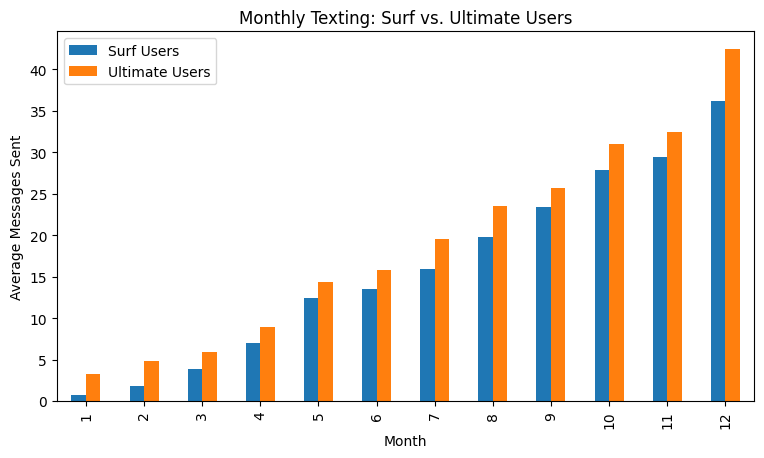

In [44]:
# Compare the number of messages users of each plan tend to send each month
# create a pivot table showing average user message count by plan by month
monthly_text_pivot=monthly_activity.pivot_table(index='month', columns='plan', values='message_count', aggfunc='mean')
print(monthly_text_pivot)
print()
# plot a bar plot to visualize it
monthly_text_pivot_plot=monthly_text_pivot.plot(kind='bar', xlabel="Month", ylabel='Average Messages Sent', title='Monthly Texting: Surf vs. Ultimate Users',figsize=(9,4.8))
monthly_text_pivot_plot.legend(['Surf Users','Ultimate Users'])
plt.show()


In contrast to calls, average monthly texting is a bit higher for Ultimate users than for Surf users. This makes sense with the higher Ultimate text allowance. <br> <br>
Similar to calls, the plot shows average texts increasing each month. This would be consistent with the idea that users tend to use more plan services the longer they're subscribed.

Next, we'll plot a histogram to visualize the distribution of user behavior.

         message_count
user_id               
1001         41.400000
1002         29.333333
1003          4.166667
1004         22.125000
1005          5.500000
         message_count
user_id               
1000         11.000000
1006         77.000000
1008         16.800000
1011         30.916667
1013         16.000000



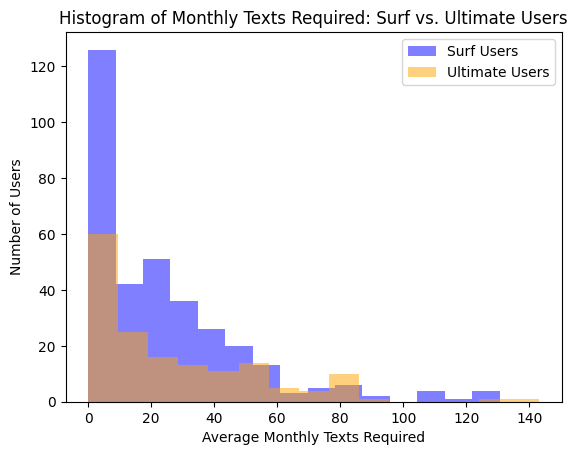

In [45]:
# Compare the number of texts users of each plan require each month. Plot a histogram.

# create a pivot table for each plan showing average monthly texts sent per user
surf_required_texts=surf_minutes.pivot_table(index='user_id', values='message_count', aggfunc='mean')
ultimate_required_texts=ultimate_minutes.pivot_table(index='user_id', values='message_count', aggfunc='mean')
# print results
print(surf_required_texts.head())
print(ultimate_required_texts.head())
print()
# plot histograms for both pivot tables
plt.hist(surf_required_texts['message_count'], bins=15, alpha=0.5, color='blue', label='Surf Users')
plt.hist(ultimate_required_texts['message_count'], bins=15, alpha=0.5, color='orange', label='Ultimate Users')
# add chart elements
plt.xlabel('Average Monthly Texts Required')
plt.ylabel('Number of Users')
plt.title('Histogram of Monthly Texts Required: Surf vs. Ultimate Users')
plt.legend(['Surf Users','Ultimate Users'])
plt.locator_params(axis='x', nbins=15)

plt.show()

This histogram is also right-skewed, with a significantly higher frequency of users from both plans needing very few text messages. This might be due to the popularity of messaging apps such as WhatsApp vs SMS.

Now we calculate the mean, variance, and standard deviation of number of text messages to reason on whether users on the different plans have different behaviours for their texting.

In [46]:
# Calculate the mean, variance, and standard deviation of the monthly text amounts

# calculate mean of monthly text amounts for each plan
surf_text_mean=surf_minutes['message_count'].mean()
ultimate_text_mean=ultimate_minutes['message_count'].mean()
# calculate variance of monthly text amounts for each plan
surf_text_variance=np.var(surf_minutes['message_count'])
ultimate_text_variance=np.var(ultimate_minutes['message_count'])
# calculate standard deviation as the square root of the variance
surf_text_std=np.sqrt(surf_text_variance)
ultimate_text_std=np.sqrt(ultimate_text_variance)

# print results
print('Mean monthly texts sent, Surf users:',surf_text_mean)
print('Mean monthly texts sent, Ultimate users:',ultimate_text_mean)
print('Variance of monthly texts sent, Surf users:',surf_text_variance)
print('Variance of monthly texts sent, Ultimate users:',ultimate_text_variance)
print('Standard deviation of monthly texts sent, Surf users:',surf_text_std)
print('Standard deviation of monthly texts sent, Ultimate users:',ultimate_text_std)

Mean monthly texts sent, Surf users: 21.620644022937803
Mean monthly texts sent, Ultimate users: 24.964912280701753
Variance of monthly texts sent, Surf users: 987.5393709129804
Variance of monthly texts sent, Ultimate users: 1116.7097568482611
Standard deviation of monthly texts sent, Surf users: 31.425139155029694
Standard deviation of monthly texts sent, Ultimate users: 33.41720749626248


The mean, variance, and standard deviation for texts is also slightly higher for Ultimate users, suggesting more usage and a wider distribution.<br><br> Now, we plot boxplots to visualize the distribution for each plan's users.

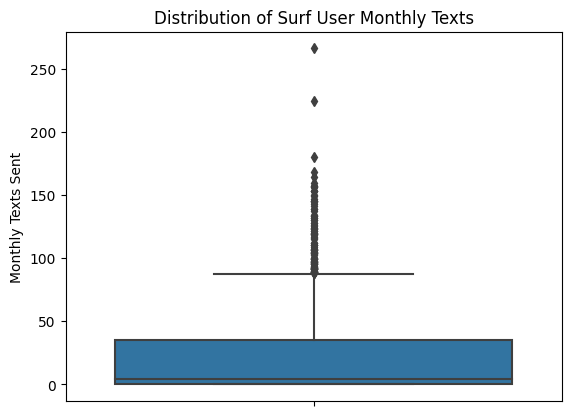

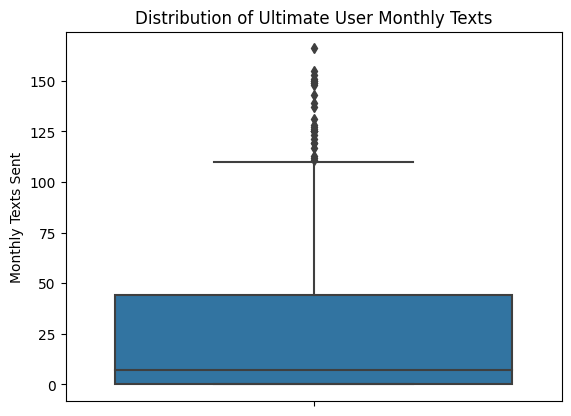

In [47]:
# create boxplot for Surf users
sns.boxplot(y=surf_minutes['message_count'])

# add labels
plt.title('Distribution of Surf User Monthly Texts')
plt.ylabel('Monthly Texts Sent')

plt.show()

# create boxplot for Ultimate users
sns.boxplot(y=ultimate_minutes['message_count'])

# add labels
plt.title('Distribution of Ultimate User Monthly Texts')
plt.ylabel('Monthly Texts Sent')

plt.show()

These boxplots are also very similar, the main differences are that the fourth quartile is a bit higher for Ultimate users and Surf users have far more outliers. Interestingly, the most active Surf texters are sending more texts than the most active Ultimate texters despite their lower text allowance.  The median is much closer to the 1st quartile for texts vs. calls, indicating a higher proportion more users who are sending very few texts. 

### Internet

We'll do the same analysis on internet behavior. First we look at the monthly internet usage by plan.

plan           surf      ultimate
month                            
1        324.990667   1456.440526
2       1826.826500   3867.795484
3       3410.501333   5362.395610
4       4832.339919   6510.668269
5       7202.008926   7417.076769
6       8200.267017   8286.003333
7       9906.417902   9740.807273
8      11578.058213  10903.837328
9      12622.500667  11491.407717
10     14245.786146  13829.116000
11     14868.196141  14326.344636
12     17009.219056  17292.512312



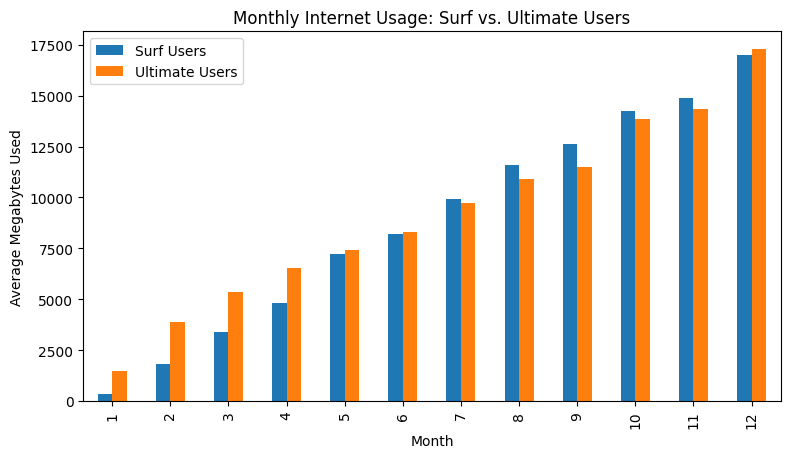

In [48]:
# Compare the amount of mb users of each plan tend to use each month
# create a pivot table showing average user mb use by plan by month
monthly_mb_pivot=monthly_activity.pivot_table(index='month', columns='plan', values='monthly_mb', aggfunc='mean')
print(monthly_mb_pivot)
print()
# plot a bar plot to visualize it
monthly_mb_pivot_plot=monthly_mb_pivot.plot(kind='bar', xlabel="Month", ylabel='Average Megabytes Used', title='Monthly Internet Usage: Surf vs. Ultimate Users',figsize=(9,4.8))
monthly_mb_pivot_plot.legend(['Surf Users','Ultimate Users'])
plt.show()

Again we see internet usage increasing each month. <br> <br>
I'm not sure how to explain the fact that Surf users outpace Ultimate users in internet usage from months 7-11. I would also expect more Surf users to curb their use after getting close to their 15 GB limit in month 11, but perhaps they didn't consider the extra charge to be a big deal.

Next, we'll plot a histogram to visualize the distribution of user data required. We'll use the GB amounts since this reflects the amount users need considering Megaline rounds MB to GB.

         monthly_gb
user_id            
1001      16.200000
1002      13.666667
1003       2.250000
1004      19.625000
1005       8.500000
         monthly_gb
user_id            
1000            2.0
1006           17.5
1008           11.2
1011           11.0
1013           20.0



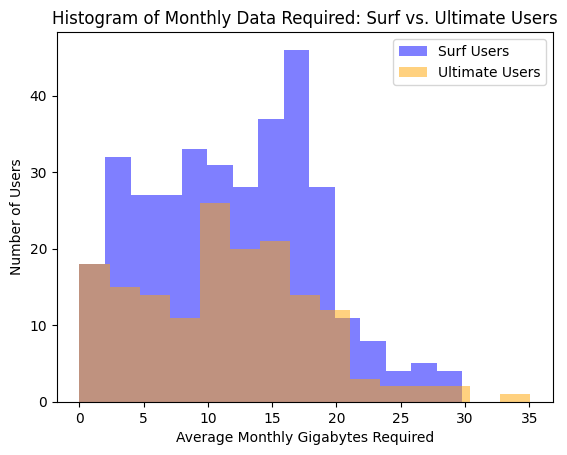

In [49]:
# Compare the GBs users of each plan require each month. Plot a histogram.

# create a pivot table for each plan showing average GBs required per user
surf_required_gb=surf_minutes.pivot_table(index='user_id', values='monthly_gb', aggfunc='mean')
ultimate_required_gb=ultimate_minutes.pivot_table(index='user_id', values='monthly_gb', aggfunc='mean')
# print results
print(surf_required_gb.head())
print(ultimate_required_gb.head())
print()
# plot histograms for both pivot tables
plt.hist(surf_required_gb['monthly_gb'], bins=15, alpha=0.5, color='blue', label='Surf Users')
plt.hist(ultimate_required_gb['monthly_gb'], bins=15, alpha=0.5, color='orange', label='Ultimate Users')
# add chart elements
plt.xlabel('Average Monthly Gigabytes Required')
plt.ylabel('Number of Users')
plt.title('Histogram of Monthly Data Required: Surf vs. Ultimate Users')
plt.legend(['Surf Users','Ultimate Users'])
plt.locator_params(axis='x', nbins=15)

plt.show()

This histogram is also right-skewed, though it does show more mid-range frequency than the other two services. The Surf peak sits at ~17-18 GB, which is above the package allowance of 15 GB. Ultimate users are more right-skewed, though some portion is still going over the 30 GB limit.

Now we calculate the mean, variance, and standard deviation of internet usage to reason on whether users on the different plans have different behaviours for their usage. We will go back to using the mb values here to more accurately reflect actual usage.

In [50]:
# Calculate the mean, variance, and standard deviation of monthly mb amounts

# calculate mean of monthly mb amounts for each plan
surf_mb_mean=surf_minutes['monthly_mb'].mean()
ultimate_mb_mean=ultimate_minutes['monthly_mb'].mean()
# calculate variance of monthly mb amounts for each plan
surf_mb_variance=np.var(surf_minutes['monthly_mb'])
ultimate_mb_variance=np.var(ultimate_minutes['monthly_mb'])
# calculate standard deviation as the square root of the variance
surf_mb_std=np.sqrt(surf_mb_variance)
ultimate_mb_std=np.sqrt(ultimate_mb_variance)

# print results
print('Mean monthly internet usage in MBs, Surf users:',surf_mb_mean)
print('Mean monthly internet usage in MBs, Ultimate users:',ultimate_mb_mean)
print('Variance of internet usage in MBs, Surf users:',surf_mb_variance)
print('Variance of internet usage in MBs, Ultimate users:',ultimate_mb_variance)
print('Standard deviation of internet usage in MBs, Surf users:',surf_mb_std)
print('Standard deviation of internet usage in MBs, Ultimate users:',ultimate_mb_std)

Mean monthly internet usage in MBs, Surf users: 11489.27213498015
Mean monthly internet usage in MBs, Ultimate users: 11444.67569713758
Variance of internet usage in MBs, Surf users: 102768661.7032415
Variance of internet usage in MBs, Ultimate users: 106966800.32048436
Standard deviation of internet usage in MBs, Surf users: 10137.48793850042
Standard deviation of internet usage in MBs, Ultimate users: 10342.475541207934


The mean for internet usage is slightly higher for Surf users, while the variance and standard deviation is slightly lower.<br><br> Now, we plot boxplots to visualize the distribution for each plan's users.

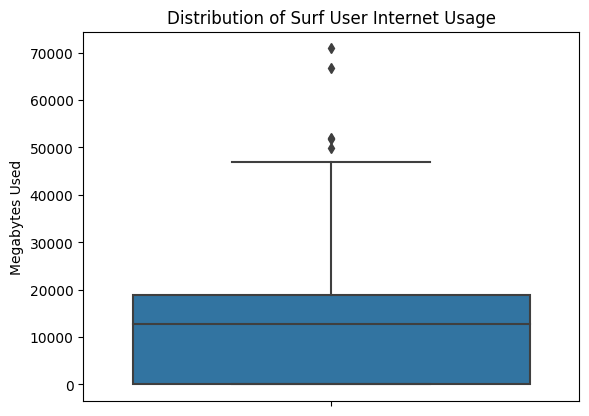

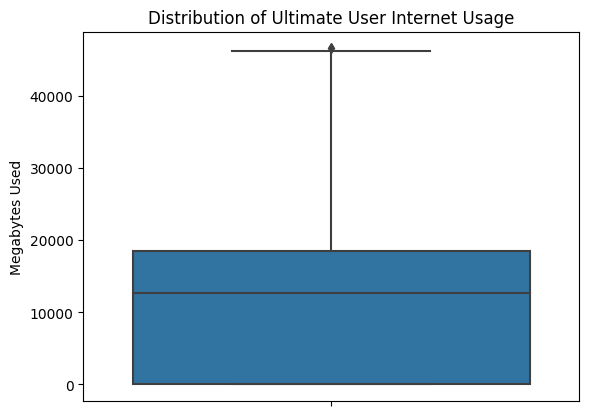

In [51]:
# create boxplot for Surf users
sns.boxplot(y=surf_minutes['monthly_mb'])

# add labels
plt.title('Distribution of Surf User Internet Usage')
plt.ylabel('Megabytes Used')

plt.show()

# create boxplot for Ultimate users
sns.boxplot(y=ultimate_minutes['monthly_mb'])

# add labels
plt.title('Distribution of Ultimate User Internet Usage')
plt.ylabel('Megabytes Used')

plt.show()

In these boxplots, the median is much closer to the 3rd quartile vs calls and texts, while the 1st quartile is still flush with the minimum. This suggests that a good portion of users don't use any internet, but those that do tend to use it more than calls and texts. There are more outliers for Surf users, and the most active internet "Surfers" are using far more data than their Ultimate counterparts. Perhaps it makes sense for some Surf users to pay a lower monthly fee and have just a few months (e.g., while traveling) where they use a lot of data.

## Revenue

Now it's time to statistically describe the revenue between the plans. First we'll look at the monthly revenue by plan.

plan        surf   ultimate
month                      
1      20.000000  70.000000
2      22.159500  70.000000
3      26.629444  71.365854
4      28.351048  71.211538
5      34.277651  70.323077
6      35.689503  70.885057
7      45.188098  71.131313
8      50.284468  71.750000
9      49.116353  71.377953
10     57.377882  71.814815
11     54.582669  71.437086
12     67.425192  73.106250



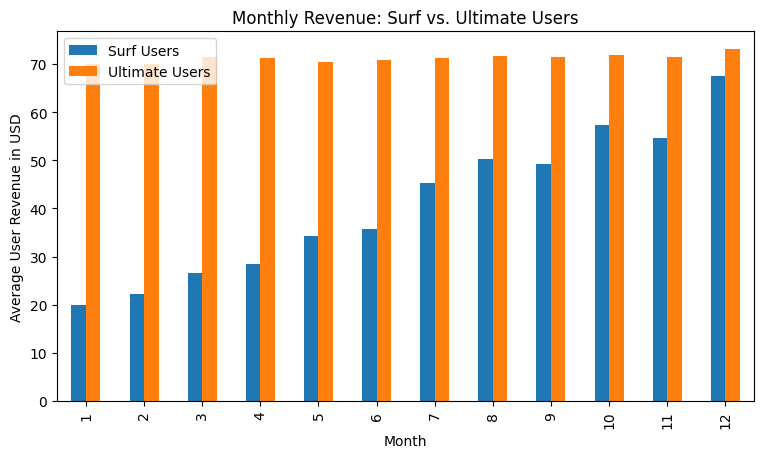

In [52]:
# Compare the amount of user revenue from each plan by month
# create a pivot table showing average user revenue by plan by month
monthly_rev_pivot=monthly_activity.pivot_table(index='month', columns='plan', values='monthly_revenue', aggfunc='mean')
print(monthly_rev_pivot)
print()
# plot a bar plot to visualize it
monthly_rev_pivot_plot=monthly_rev_pivot.plot(kind='bar', xlabel="Month", ylabel='Average User Revenue in USD', title='Monthly Revenue: Surf vs. Ultimate Users',figsize=(9,4.8))
monthly_rev_pivot_plot.legend(['Surf Users','Ultimate Users'])
plt.show()

Revenue is higher and stays fairly stable for Utimate users month over month, while it starts low and then climbs almost every month for Surf users. This makes sense as the Ultimate base fee is higher, and it's harder for Ultimate users to incur extra charges with their bigger usage allowances. It would be interesting to see how many Surf users continue to increase their usage past month 12.<br><br> Now, we'll plot a historgram to show the distribution of user revenue.

         monthly_revenue
user_id                 
1001           50.018000
1002           33.333333
1003           31.510000
1004           76.250000
1005           30.000000
         monthly_revenue
user_id                 
1000                70.0
1006                77.0
1008                70.0
1011                70.0
1013                70.0



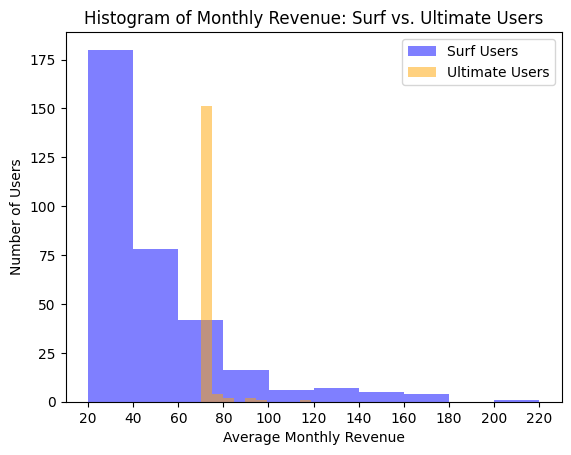

In [53]:
# Compare the monthly revenue from users of each plan. Plot a histogram.

# create a pivot table for each plan showing average revenue per user
surf_avg_rev=surf_minutes.pivot_table(index='user_id', values='monthly_revenue', aggfunc='mean')
ultimate_avg_rev=ultimate_minutes.pivot_table(index='user_id', values='monthly_revenue', aggfunc='mean')
# print results
print(surf_avg_rev.head())
print(ultimate_avg_rev.head())
print()
# plot histograms for both pivot tables
plt.hist(surf_avg_rev['monthly_revenue'], bins=10, alpha=0.5, color='blue', label='Surf Users')
plt.hist(ultimate_avg_rev['monthly_revenue'], bins=10, alpha=0.5, color='orange', label='Ultimate Users')
# add chart elements
plt.xlabel('Average Monthly Revenue')
plt.ylabel('Number of Users')
plt.title('Histogram of Monthly Revenue: Surf vs. Ultimate Users')
plt.legend(['Surf Users','Ultimate Users'])
plt.locator_params(axis='x', nbins=15)

plt.show()

As to be expected, the majority of users of both plans provide a monthly revenue right at their monthly subscription fee. Interestingly, a number of Surf users are paying a higher monthly charge than the Ultimate plan, with some paying more than double. Surf users who go above their package limits end up generating far more revenue than Ultimate users with the same usage levels.<br><br>Now we calculate the mean, variance, and standard deviation of monthly revenue.

In [54]:
# Calculate the mean, variance, and standard deviation of monthly revenue

# calculate mean of monthly revenue for each plan
surf_rev_mean=surf_minutes['monthly_revenue'].mean()
ultimate_rev_mean=ultimate_minutes['monthly_revenue'].mean()
# calculate variance of monthly mb amounts for each plan
surf_rev_variance=np.var(surf_minutes['monthly_revenue'])
ultimate_rev_variance=np.var(ultimate_minutes['monthly_revenue'])
# calculate standard deviation as the square root of the variance
surf_rev_std=np.sqrt(surf_rev_variance)
ultimate_rev_std=np.sqrt(ultimate_rev_variance)

# print results
print('Mean monthly revenue in USD, Surf users:',surf_rev_mean)
print('Mean monthly revenue in USD, Ultimate users:',ultimate_rev_mean)
print('Variance of monthly revenue in USD, Surf users:',surf_rev_variance)
print('Variance of monthly revenue in USD, Ultimate users:',ultimate_rev_variance)
print('Standard deviation of monthly revenue in USD, Surf users:',surf_rev_std)
print('Standard deviation of monthly revenue in USD, Ultimate users:',ultimate_rev_std)

Mean monthly revenue in USD, Surf users: 48.24489633877371
Mean monthly revenue in USD, Ultimate users: 71.53831948291783
Variance of monthly revenue in USD, Surf users: 2479.2951762023113
Variance of monthly revenue in USD, Ultimate users: 87.3990394657977
Standard deviation of monthly revenue in USD, Surf users: 49.79252128786322
Standard deviation of monthly revenue in USD, Ultimate users: 9.348745341798422


The mean for revenue sits at the monthly charge for Ultimate users, while it's more than double the monthly charge for Surf users. The variance and standard deviation for Surf users is significantly higher, indicating a much wider distribution.<br><br> Now, we plot boxplots to visualize the distribution for each plan's users.

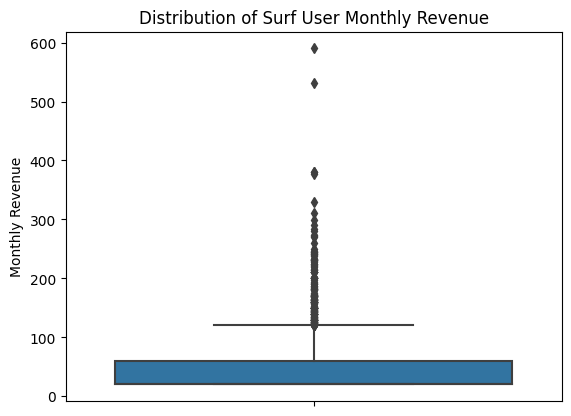

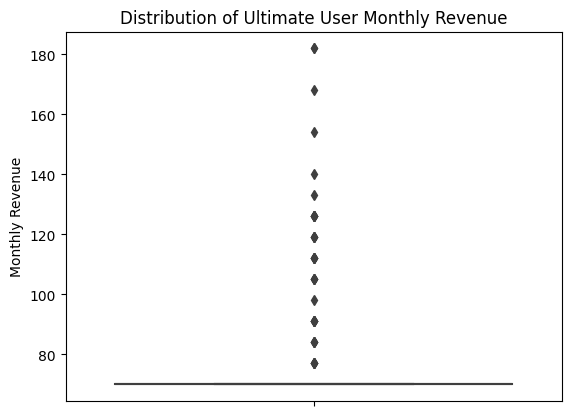

In [55]:
# create boxplot for Surf users
sns.boxplot(y=surf_minutes['monthly_revenue'])

# add labels
plt.title('Distribution of Surf User Monthly Revenue')
plt.ylabel('Monthly Revenue')

plt.show()

# create boxplot for Ultimate users
sns.boxplot(y=ultimate_minutes['monthly_revenue'])

# add labels
plt.title('Distribution of Ultimate User Monthly Revenue')
plt.ylabel('Monthly Revenue')

plt.show()

The distribution for Ultimate users is extremely narrow, with most users generating revenue right at the base charge. The Surf user distribution is a bit wider, with more users paying above the base charge and a number of outliers paying more than 10x the base charge. Looking at the space between the third and fourth quartiles for Surf users, a much larger proportion of Surf users are generating monthly revenue above $70 than Ultimate users.

## Test statistical hypotheses

Now it's time to test the hypothesis that the average revenue from users of the Ultimate and Surf calling plans differs.


We start with the null hypothesis: The mean revenue from users of the Ultimate plan equals the mean revenue from users of the Surf plan.<br><br>
Therefore, our alternative hypothesis would be that the mean revenue from users of the Ultimate plan differs from the mean revenue from users of the Surf plan.

To test this, we use a two-sided T test because we are looking at whether it differs generally, not whether it is specifically higher or lower. We define the alpha value at 0.05, as is standard.

In [56]:
# Test the hypotheses

alpha = 0.05  # critical statistical significance level
# if the p-value is less than alpha, we reject the hypothesis

# because the variance is so much higher for Surf users vs Ultimate, we set equal_var as False

results = st.ttest_ind(surf_minutes['monthly_revenue'], ultimate_minutes['monthly_revenue'], equal_var=False)
# print the p value
print('p-value: ', results.pvalue)
# if the p-value is less than alpha, we reject the hypothesis
if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")


p-value:  2.206502916796134e-94
We reject the null hypothesis


Our test shows that the average revenue from users of the two plans does differ, and the difference is statistically significant.

Now we'll test the hypothesis that the average revenue from users in the NY-NJ area is different from that of the users from the other regions. <br><br>We start with the null hypothesis: The mean revenue from NY-NJ users equals the mean revenue of users from other regions. <br><br>Therefore, our alternative hypothesis would be that the mean revenue from NY-NJ users differs from the mean revenue of users from other regions.<br><br>

To test this, we again use a two-sided T test. We define the alpha value at 0.05 here as well.


In [57]:
# add the region information from the users table
monthly_activity=pd.merge(monthly_activity, users[['user_id','ny_nj']], on='user_id', how='left')

# filter monthly_activity to create a dataset for each region
ny_nj_users=monthly_activity[monthly_activity['ny_nj']==1]
other_region_users=monthly_activity[monthly_activity['ny_nj']==0]

# Test the hypotheses

alpha = 0.05  # critical statistical significance level
# if the p-value is less than alpha, we reject the hypothesis

results = st.ttest_ind(ny_nj_users['monthly_revenue'], other_region_users['monthly_revenue'])
# print the p value
print('p-value: ', results.pvalue)
# if the p-value is less than alpha, we reject the hypothesis
if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

p-value:  0.038568180819670214
We reject the null hypothesis


Our test shows that average revenue between NY-NJ users and users from other regions also differs, and the difference is statistically significant.

## General conclusion

This analysis reveals a number of preliminary insights about user behavior and revenue from each plan. On average, the Ultimate users bring in more monthly revenue than the Surf users because users of both plans tend to keep their usage within the package limits. However, a much higher proportion of Surf users pay far more than the base fee because they incur so many extra charges from above-limit usage of services, particularly for internet services. In fact, there is a much higher proportion of Surf users paying above the Ultimate base fee of $70 than Ultimate users, and considering how many more Surf users there are than Ultimate users, it could be more profitable to advertise the Surf plan more heavily. Particularly if the Surf plan has a higher conversion rate from advertising than the Ultimate plan (which seems likely due to its lower monthly fee), focusing on marketing the Surf plan could lock in a lot of customers who sign up believing they won’t use many services, and end up using far more than they thought and consequently racking up far more in monthly charges than they would on the Ultimate plan. 

In terms of behavior, the median user for both plans doesn’t use many services. However, usage does seem to increase on average the longer a user is subscribed. This is based on the assumption that users who had an active subscription (according to  their registration and churn dates) but didn’t have any service usage for some months (according to the calls, internet, and messages records) had zero usage for those months. If the service datasets are missing records, the pattern might be different in reality.

Based on statistical testing using T tests, we cannot reject the following hypotheses:
* The average revenue from users of Ultimate and Surf calling plans differs
* The average revenue from users in NY-NJ area is different from that of the users from other regions

After this preliminary analysis, it would be helpful to look beyond this dataset and analyze users beyond the 2018 period to look at whether they continue to increase their usage over time, and also whether they decide to switch plans or churn. After testing the above hypotheses, it would also be worth digging into why the average revenue between these user groups differs.